<center>

# ⠀
---

# **Analyse Numérique**

## **Méthodes directes de résolution de systèmes linéaires**

---
<br>

**MANSOURI Koussay**


<br>



</center>

---

## I - Autour de la décomposition $LU$

### I.1 - Descendre en bas

> Créer une fonction `resol_syst_inf(A,b)` qui prend en entrée : une matrice carrée triangulaire inférieure inversible $A$, un vecteur $b$ et retourne la solution $x$ du système $Ax = b$ (avec $b$ supposé de la bonne taille).
>
> Tester votre fonction avec la matrice :
>
> $$
> A = (a_{i,j})_{i=1,...,n, \, j=1,...,n} \quad \text{où} \quad a_{i,j} =
> \begin{cases}
> \left( \sqrt{i} \right)^j & \text{si } i \geqslant j \\
> 0 & \text{sinon}
> \end{cases}
> $$
> et un vecteur $b$ de votre choix, et vérifier votre résultat.


Commençons par importer nos meilleurs amis pour la suite du TP !

In [ ]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
import time

Pour ce faire, nous allons définir notre vecteur (ligne) solution. Ensuite, pour chaque ligne $i$, on calcule :
$$x_i = \frac{b_i - \sum_{j=0}^{i-1}A_{ij}x_{j}}{A_{ii}}$$

En soit, tout repose sur le fait que l'on connait déjà les éléments $x_j$ pour $j<i$, d'où leur substitution pour faire la différence à l'aide de la somme.

In [ ]:
def resol_syst_inf(A,b) :
  n = len(b)
  x = np.zeros(n)
  for i in range(n):
    somme = sum(A[i, j] * x[j] for j in range(i))
    x[i] = (b[i] - somme) / A[i, i]
  return x

On peut alors tester !

In [ ]:
n = 3
A = np.zeros((n, n))
for i in range(n):
  for j in range(n):
    if i >= j:
      A[i, j] = sqrt(i + 1) ** (j + 1)
b = np.array([1, 2, 3])

x = resol_syst_inf(A, b)

print("Matrice A :\n", A)
print("Second membre b :", b)
print("Solution x :", x)

Matrice A :
 [[1.         0.         0.        ]
 [1.41421356 2.         0.        ]
 [1.73205081 3.         5.19615242]]
Second membre b : [1 2 3]
Solution x : [1.         0.29289322 0.07491496]


In [ ]:
for i in range(n):
  s = sum(A[i, j] * x[j] for j in range(n))
  print(s)

1.0
2.0
3.0


Tout va bien, passons à la suite.

---

### I.2 - Monter en haut

> Même question pour une matrice carrée triangulaire supérieure inversible ; la fonction créée s’appellera `resol_syst_sup(A,b)`.
>
> Tester votre fonction avec la matrice :
>
> $$
> A = (a_{i,j})_{i=1,...,n, \, j=1,...,n} \quad \text{où} \quad a_{i,j} =
> \begin{cases}
> \left( \sqrt{i} \right)^j & \text{si } i \leqslant j \\
> 0 & \text{sinon}
> \end{cases}
> $$
> et un vecteur $b$ de votre choix, et vérifier votre résultat.


Ici, on fait de même, mais on part du bas de la matrice (ligne $n-1$) afin de remonter en haut (ligne $0$ si vous avez bien suivi jusqu'ici !!)

Dans ce cadre, on calcule désormais pour chaque ligne :
$$x_i = \frac{b_i - \sum_{j=i+1}^{n-1}A_{ij}x_{j}}{A_{ii}}$$

In [ ]:
def resol_syst_sup(A,b) :
  n = len(b)
  x = np.zeros(n)
  for i in range(n - 1, -1, -1):
    somme = sum(A[i, j] * x[j] for j in range(i +1, n))
    x[i] = (b[i] - somme) / A[i, i]
  return x

A nos tests.

In [ ]:
n = 3
A = np.zeros((n, n))
for i in range(n):
  for j in range(n):
    if i <= j:
      A[i, j] = sqrt(i + 1) ** (j + 1)
b = np.array([1, 2, 3])

x = resol_syst_sup(A, b)

print("Matrice A :\n", A)
print("Second membre b :", b)
print("Solution x :", x)

Matrice A :
 [[1.         1.         1.        ]
 [0.         2.         2.82842712]
 [0.         0.         5.19615242]]
Second membre b : [1 2 3]
Solution x : [0.23914631 0.18350342 0.57735027]


In [ ]:
for i in range(n):
  s = sum(A[i, j] * x[j] for j in range(n))
  print(s)

1.0
2.0
3.0


C'est correct ! On peut enfin passer à la partie qui me fait du pied.

---

### I.3 - Factorisation LU

> Créer la fonction `factoLU(A)` qui retourne le couple $(L, U)$ donnant la factorisation $LU$ d’une matrice $A$. Si la valeur du plus petit pivot utilisé (en valeur absolue) est inférieure à $10^{-10}$, faire en sorte que la fonction s’arrête et avertisse l’utilisateur.  
>
> **Attention**, vous devez appliquer la formulation de la décomposition $LU$ qui a été présentée en cours - ou alors il faudra être capable d’expliquer pourquoi votre version est équivalente à celle du cours. Cette formulation est rappelée dans le document *Résumé de l’algorithme LU* disponible dans Moodle. La dernière page de ce document propose deux versions de l’algorithme, vous pouvez choisir.
>
> Tester votre fonction avec la matrice
>
> $$
> A = (a_{i,j})_{i=1,...,n, \, j=1,...,n} \quad \text{où} \quad a_{i,j} = \left( \sqrt{i} \right)^j
> $$
> et vérifier votre résultat.


Nous utiliserons scrupuleusement la méthode du cours afin de ne pas avoir à nous justifier (et surtout pour ne pas faire n'importe quoi !).

Noton que l'on peut enfin réutiliser notre cher **matmul** (`@`), ce qui nous rend le code bien plus court et élégant ! (nb : il s'agit d'une built-in de Python, donc pas d'usage de fonction non-élémentaire de Numpy !

In [ ]:
def factoLU(A) :
  n = len(A)
  L = np.identity(n)
  U = np.zeros((n, n))
  for k in range(n):
    U[k, k:n] = A[k, k:n] - L[k, :k] @ U[:k, k:n]
    if abs(U[k, k]) < 10**(-10):
      print("pivot beaucouuuup trop petit (<10^(-10))")
      return 0
    L[k+1:n, k] = (A[k+1:n, k] - L[k+1:n, :k] @ U[:k, k]) / U[k, k]
  return L, U

In [ ]:
n = 3
A = np.zeros((n, n))
for i in range(n):
  for j in range(n):
    A[i, j] = sqrt(i + 1) ** (j + 1)
b = np.array([1, 2, 3])

L, U = factoLU(A)

print("Matrice A :\n", A)
print("Matrice L :\n",L)
print("Matrice U :\n", U)

print("L*U :\n", L@U)

Matrice A :
 [[1.         1.         1.        ]
 [1.41421356 2.         2.82842712]
 [1.73205081 3.         5.19615242]]
Matrice L :
 [[1.         0.         0.        ]
 [1.41421356 1.         0.        ]
 [1.73205081 2.16452466 1.        ]]
Matrice U :
 [[1.         1.         1.        ]
 [0.         0.58578644 1.41421356]
 [0.         0.         0.40300148]]
L*U :
 [[1.         1.         1.        ]
 [1.41421356 2.         2.82842712]
 [1.73205081 3.         5.19615242]]


Après un peu d'huile de coude, de sueur et d'arrangements dans les indices des slices, on y est ; tout fonctionne pour le mieux !

---

### I.4 - Et un problème de résolu !

> À l’aide des fonctions précédentes, programmer la fonction `resol_syst_lu(A,b)` qui retourne la solution $x$ du système $Ax = b$, où $A$ est supposée admettre une factorisation $LU$.  
>
> Tester votre fonction avec la matrice $A$ de la question 3 et $b = (10, 38, 119, 287)^T$, et vérifier votre résultat.

Notre fonction consistera à factoriser $A$ en $L$ et $U$ avec notre dernière fonction, puis on résout $Ly=b$ et $Ux=y$.

In [ ]:
def resol_syst_lu(A,b):
  L, U = factoLU(A)
  y = resol_syst_inf(L, b)
  x = resol_syst_sup(U, y)
  return x

On peut alors le tester :

In [ ]:
n = 4
A = np.zeros((n, n))
for i in range(n):
  for j in range(n):
    A[i, j] = sqrt(i + 1) ** (j + 1)
b = np.array([10, 38, 119, 287])

x = resol_syst_lu(A, b)

print("Matrice A :\n", A)
print("Second membre b :", b)
print("Solution x :", x)

Matrice A :
 [[ 1.          1.          1.          1.        ]
 [ 1.41421356  2.          2.82842712  4.        ]
 [ 1.73205081  3.          5.19615242  9.        ]
 [ 2.          4.          8.         16.        ]]
Second membre b : [ 10  38 119 287]
Solution x : [-167.84127363  455.33753448 -405.15907287  127.66281202]


In [ ]:
for i in range(n):
  s = sum(A[i, j] * x[j] for j in range(n))
  print(s)

10.000000000000014
37.99999999999994
119.0
286.9999999999998


C'est cohérent ! Bon, pas d'assert pour cette fois, ça fait un an que le cours de MNA nous appris à ne plus faire confiance aux flottants à double précision !

---

## II - Application : Calcul des tensions dans une structure métallique

Les TPs d'Analyse Numérique furent une belle aventure dans laquelle l'élégance de la rédaction fut une motivation sans précédent. Fini les geq, bonjour les geqslant. Il en est de même pour les partial remplacant les delta, on bien même l'acquisition de nouveaux termes rendant les propos toujours plus abscons !

Toutefois, je dois enfin m'avouer vaincu : inpossible de tracer la Figure 1 à l'aide de TikZ. Ainsi, la suite du TP ne sera sûrement pas à la hauteur de vos attentes 😔

### II.1 - Forme matricielle

> Écrire sous forme matricielle $AT = b$ ce système d’équations.

Soit la matrice $A$ :
$$A:= \left[
\begin{matrix}
-\cos(\frac{\pi}{6}) & 0 & \cos(\frac{\pi}{4}) & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
-\sin(\frac{\pi}{6}) & 0 & -\sin(\frac{\pi}{4}) & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & -1 & -\cos(\frac{\pi}{4}) & 0 & \cos(\frac{\pi}{4}) & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & \sin(\frac{\pi}{4}) & 0 & \sin(\frac{\pi}{4}) & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & -1 & -\cos(\frac{\pi}{4}) & 0 & \cos(\frac{\pi}{4}) & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & -\sin(\frac{\pi}{4}) & 0 & -\sin(\frac{\pi}{4}) & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & -1 & -\cos(\frac{\pi}{4}) & 0 & \cos(\frac{\pi}{4}) & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \sin(\frac{\pi}{4}) & 0 & \sin(\frac{\pi}{4}) & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & -1 & -\cos(\frac{\pi}{4}) & 0 & \cos(\frac{\pi}{6}) \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -\sin(\frac{\pi}{4}) & 0 & -\sin(\frac{\pi}{6}) \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1 & -\cos(\frac{\pi}{6}) \\
\end{matrix}
\right]
$$

Soit $B$ son second membre :
$$B:= \left[
\begin{matrix}
0 \\
0 \\
0 \\
10000 \\
0 \\
0 \\
20000 \\
0 \\
0 \\
0 \\
0
\end{matrix}
\right]
$$

Un peu fastidieux, mais c'est loin d'être fini.

In [ ]:
A = np.array([
  [-cos(pi / 6), 0, cos(pi / 4), 1, 0, 0, 0, 0, 0, 0, 0],
  [-sin(pi / 6), 0, -sin(pi / 4), 0, 0, 0, 0, 0, 0, 0, 0],
  [0, -1, -cos(pi / 4), 0, cos(pi / 4), 1, 0, 0, 0, 0, 0],
  [0, 0, sin(pi / 4), 0, sin(pi / 4), 0, 0, 0, 0, 0, 0],
  [0, 0, 0, -1, -cos(pi / 4), 0, cos(pi / 4), 1, 0, 0, 0],
  [0, 0, 0, 0, -sin(pi / 4), 0, -sin(pi / 4), 0, 0, 0, 0],
  [0, 0, 0, 0, 0, -1, -cos(pi / 4), 0, cos(pi / 4), 1, 0],
  [0, 0, 0, 0, 0, 0, sin(pi / 4), 0, sin(pi / 4), 0, 0],
  [0, 0, 0, 0, 0, 0, 0, -1, -cos(pi / 4), 0, cos(pi / 6)],
  [0, 0, 0, 0, 0, 0, 0, 0, -sin(pi / 4), 0, -sin(pi / 6)],
  [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -cos(pi / 6)]
])

B = np.array([
  [0],
  [0],
  [0],
  [10000],
  [0],
  [0],
  [20000],
  [0],
  [0],
  [0],
  [0]
])


---

### II.2 - Plus de Petit Beurre ?
> En utilisant la fonction `factolu`, vérifier que la matrice $A$ n’admet pas de décomposition $LU$.

In [ ]:
factoLU(A)

pivot beaucouuuup trop petit (<10^(-10))


0

En effet, $A$ n'admet pas de décomposition $LU$, et pour cause :

---

### II.3 - Un nouveau paquet !

> Réécrire le système linéaire, en considérant la première équation (*) en dernière ligne du système, et vérifier en utilisant la fonction `factolu` que la nouvelle matrice admet cette fois une décomposition $LU$.

In [ ]:
A2 = np.array([
  [-sin(pi / 6), 0, -sin(pi / 4), 0, 0, 0, 0, 0, 0, 0, 0],
  [0, -1, -cos(pi / 4), 0, cos(pi / 4), 1, 0, 0, 0, 0, 0],
  [0, 0, sin(pi / 4), 0, sin(pi / 4), 0, 0, 0, 0, 0, 0],
  [0, 0, 0, -1, -cos(pi / 4), 0, cos(pi / 4), 1, 0, 0, 0],
  [0, 0, 0, 0, -sin(pi / 4), 0, -sin(pi / 4), 0, 0, 0, 0],
  [0, 0, 0, 0, 0, -1, -cos(pi / 4), 0, cos(pi / 4), 1, 0],
  [0, 0, 0, 0, 0, 0, sin(pi / 4), 0, sin(pi / 4), 0, 0],
  [0, 0, 0, 0, 0, 0, 0, -1, -cos(pi / 4), 0, cos(pi / 6)],
  [0, 0, 0, 0, 0, 0, 0, 0, -sin(pi / 4), 0, -sin(pi / 6)],
  [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, -cos(pi / 6)],
  [-cos(pi / 6), 0, cos(pi / 4), 1, 0, 0, 0, 0, 0, 0, 0]
])

In [ ]:
# TEST ---
factoLU(A2)

(array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [-0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [-0.        , -0.        ,  1.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [-0.        , -0.        ,  0.        ,  1.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [-0.        , -0.        ,  0.        , -0.        ,  1.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [-0.        , -0.        ,  0.        , -0.        , -0.        ,
          1.        ,  0.        ,  0.        ,  0.        ,  0.       

On peut désormais effectuer notre décomposition $LU$.

---

### II.4 - Une drôle de résolution

> Résoudre le système en utilisant la fonction `resol_syst_lu` précédemment développée.

In [ ]:
x = resol_syst_lu(A2, B)

print("Matrice A :\n", A2)
print("Second membre B :", B)
print("Solution x :", x)

Matrice A :
 [[-0.5         0.         -0.70710678  0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [ 0.         -1.         -0.70710678  0.          0.70710678  1.
   0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.70710678  0.          0.70710678  0.
   0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.         -1.         -0.70710678  0.
   0.70710678  1.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         -0.70710678  0.
  -0.70710678  0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.         -1.
  -0.70710678  0.          0.70710678  1.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.70710678  0.          0.70710678  0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.         -1. 

/tmp/ipykernel_1242/3041822395.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[i] = (b[i] - somme) / A[i, i]


In [ ]:
for i in range(11):
  s = sum(A2[i, j] * x[j] for j in range(11))
  print(s)

0.0
0.0
0.0
10000.0
0.0
0.0
20000.0
0.0
0.0
0.0
1.4551915228366852e-11


Après vérification (prudence est mère de sûreté), notre résolution de système est correcte.

---

### II.5 - Un peu de réflexion

> Quelles sont les membrures en compression ? en tension ?

Faisons l'inventaire des tensions $T_i$ dans les membrures. Notons que l'on arrondira le tronquant à l'unité (partie entière basse, soit $\lfloor T_i \rfloor$).
$$
\begin{aligned}
T_1 &= -17320 N \\
T_2 &= 5000 N\\
T_3 &= 12247 N\\
T_4 &= -23660 N\\
T_5 &= -12247 N\\
T_6 &= 22320 N\\
T_7 &= 12247 N\\
T_8 &= -30980 N\\
T_9 &= 16036 N\\
T_{10} &= 19641 N\\
T_{11} &= -22679 N\\
\end{aligned}
$$

Ainsi, les membrures en compression sont $T_1, T_4, T_5, T_8$ et $T_{11}$. A contrario, les membrures en tension sont $T_2, T_3, T_6, T_7, T_9$ et $T_{10}$.

---

### II.6 - Deux forces

> En écrivant l’équilibre des forces verticales aux rotules 1 et 7, déterminer les forces $V_1$ et $V_2$. Que peut-on dire de leur somme ?

Rolute 1 : $ V_1 + \sin(\frac\pi 6)T_1 = 0 \implies V_1 = \frac{17320}{2} = 8660N$

Rolute 7 : $ V_2 + \sin(\frac\pi 6)T_{11} = 0 \implies V_2 = \frac{22679}{2} = 11339,5N$

En calculant leur somme :
$$V_1 + V_2 = 8660 + 11339,5 = 19999,5 N \approx 20000N$$

Un résultat somme toute étrange, car nous devrions avoir $V_1 + V_2 - 10000 - 20000 = 0N$ (équilibre car forces compensées), alors que nous avons actuellement $V_1 + V_2 - 10000 - 20000 = - 10000N$.

---

## III - Accélérer $LU$ pour les matrices tridiagonales

### III.1 - Quelques ajustements

> Modifier votre fonction `factoLU()` de la première partie, pour tenir compte du fait que la matrice est tridiagonale et réduire les calculs.

In [ ]:
def factLU_tridiagonale(A):
  n = len(A)
  L = np.zeros(n)
  U = np.zeros(n)
  U[0] = A[0, 0]
  for i in range(1, n):
    L[i] = A[i, i-1] / U[i-1]
    U[i] = A[i, i] - L[i] * A[i-1, i]
  return L, U

---

### III.2 - Un joli tracé !

> Pour des matrices aléatoires de taille $n$, $n$ variant de $100$ à $1000$ par pas de $100$, mesurer la différence de temps de calcul de la décomposition $LU$, entre votre première version et celle-ci. Si le temps le permet, en donner une représentation graphique.

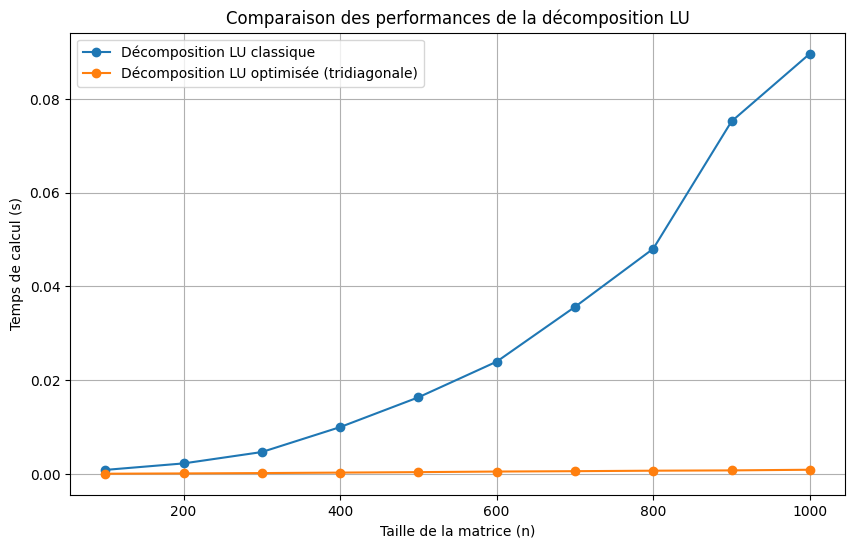

In [ ]:
def generer_tridiagonale(n):
    diagonale_principale = np.random.rand(n)
    diagonale_inferieure = np.random.rand(n-1)
    diagonale_superieure = np.random.rand(n-1)
    A = np.diag(diagonale_principale) + np.diag(diagonale_inferieure, k=-1) + np.diag(diagonale_superieure, k=1)
    return A

tailles = range(100, 1100, 100)
temps_classique = []
temps_tridiagonale = []

n_essais = 5

for n in tailles:
    temps_classique_temp = []
    temps_tridiagonale_temp = []

    for _ in range(n_essais):
        A = generer_tridiagonale(n)

        debut = time.time()
        factoLU(A)
        temps_classique_temp.append(time.time() - debut)

        debut = time.time()
        factLU_tridiagonale(A)
        temps_tridiagonale_temp.append(time.time() - debut)

    temps_classique.append(np.mean(temps_classique_temp))
    temps_tridiagonale.append(np.mean(temps_tridiagonale_temp))

plt.figure(figsize=(10, 6))
plt.plot(tailles, temps_classique, label="Décomposition LU classique", marker="o")
plt.plot(tailles, temps_tridiagonale, label="Décomposition LU optimisée (tridiagonale)", marker="o")
plt.xlabel("Taille de la matrice (n)")
plt.ylabel("Temps de calcul (s)")
plt.title("Comparaison des performances de la décomposition LU")
plt.legend()
plt.grid()
plt.show()